In [ ]:
# Benchmark: AI-generated vs Real image classification with a deep + dense CNN

import random
import time
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    balanced_accuracy_score,
)
from datasets import load_dataset
from huggingface_hub import login

SEED = 42
BATCH_SIZE = 8
IMG_HEIGHT = 160
IMG_WIDTH = 160
EPOCHS = 20
LEARNING_RATE = 1e-4

# Hugging Face dataset repo.
# Expected schema:
#   image -> image data
#   label -> 1 for real, 0 for fake
DATASET_REPO = "ShreyashDhoot/AI_vs_Real"

# Paste your Hugging Face access token here, or set it from an environment variable.
HF_TOKEN = ""

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if HF_TOKEN and HF_TOKEN != "PASTE_YOUR_HF_ACCESS_TOKEN_HERE":
    login(token=HF_TOKEN)
    print("Hugging Face token configured.")
else:
    print("No Hugging Face token configured; loading will use anonymous access.")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
else:
    print("No GPU detected; training will run on CPU and may be slow.")

print("TensorFlow version:", tf.__version__)
print("Hugging Face dataset:", DATASET_REPO)

2026-04-09 13:05:44.289795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775739944.719368     142 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775739944.846515     142 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Hugging Face token configured.
GPUs detected: 2
TensorFlow version: 2.18.0
Hugging Face dataset: ShreyashDhoot/AI_vs_Real


In [6]:
# Data loading and split from Hugging Face Hub

def load_dataset_with_retry(repo_id, token=None, max_attempts=5, initial_delay=5):
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            return load_dataset(repo_id, token=token)
        except Exception as exc:
            last_error = exc
            message = str(exc)
            if "429" not in message and "Too Many Requests" not in message:
                raise
            if attempt == max_attempts:
                break
            delay = initial_delay * attempt
            print(f"Hugging Face rate limited the request. Retrying in {delay} seconds... (attempt {attempt}/{max_attempts})")
            time.sleep(delay)
    raise last_error

loaded_dataset = load_dataset_with_retry(DATASET_REPO, token=HF_TOKEN if HF_TOKEN != "PASTE_YOUR_HF_ACCESS_TOKEN_HERE" else None)

# Support either a single Dataset or a DatasetDict with named splits.
if hasattr(loaded_dataset, "keys"):
    if "train" in loaded_dataset:
        raw_dataset = loaded_dataset["train"]
    else:
        first_split_name = next(iter(loaded_dataset.keys()))
        raw_dataset = loaded_dataset[first_split_name]
else:
    raw_dataset = loaded_dataset

# Ensure labels are present and images are accessible as PIL images.
required_columns = {"image", "label"}
if not required_columns.issubset(set(raw_dataset.column_names)):
    raise ValueError("The dataset must contain 'image' and 'label' columns.")

# Create train/validation/test splits from the HF dataset without materializing images.
if not hasattr(raw_dataset, "train_test_split"):
    raise TypeError("Expected a map-style Hugging Face Dataset. Streaming datasets are not supported in this notebook because they cannot be safely split without extra buffering.")

split_1 = raw_dataset.train_test_split(test_size=0.2, seed=SEED)
train_raw = split_1["train"]
remaining_raw = split_1["test"]

split_2 = remaining_raw.train_test_split(test_size=0.5, seed=SEED)
val_raw = split_2["train"]
test_raw = split_2["test"]

class_names = ["fake", "real"]

print("Dataset loaded from:", DATASET_REPO)
print("Train size:", len(train_raw))
print("Validation size:", len(val_raw))
print("Test size:", len(test_raw))
print("Label mapping: 0 -> fake, 1 -> real")

# Build tf.data pipelines that decode and resize one image at a time.
def split_generator(hf_split):
    for example in hf_split:
        image = example["image"].convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
        image = np.asarray(image, dtype=np.uint8)
        label = np.int32(example["label"])
        yield image, label

output_signature = (
    tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.uint8),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(train_raw),
    output_signature=output_signature,
).map(lambda image, label: (tf.cast(image, tf.float32), label), num_parallel_calls=AUTOTUNE)
val_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(val_raw),
    output_signature=output_signature,
).map(lambda image, label: (tf.cast(image, tf.float32), label), num_parallel_calls=AUTOTUNE)
test_ds = tf.data.Dataset.from_generator(
    lambda: split_generator(test_raw),
    output_signature=output_signature,
).map(lambda image, label: (tf.cast(image, tf.float32), label), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

Dataset loaded from: ShreyashDhoot/AI_vs_Real
Train size: 144381
Validation size: 18048
Test size: 18048
Label mapping: 0 -> fake, 1 -> real


In [8]:
# Compute class weights from Hugging Face labels
train_labels_only = np.asarray(train_raw["label"], dtype=np.int32)
train_label_counts = np.bincount(train_labels_only, minlength=2)
train_total = int(train_label_counts.sum())
if train_total == 0:
    raise ValueError("No training samples found in the Hugging Face dataset.")

# Keras class_weight expects mapping class_index -> weight
class_weight = {
    label: train_total / (len(class_names) * max(int(count), 1))
    for label, count in enumerate(train_label_counts)
}

print("Class distribution (train):", {"fake": int(train_label_counts[0]), "real": int(train_label_counts[1])})
print("Class weights:", class_weight)

Class distribution (train): {'fake': 86393, 'real': 57988}
Class weights: {0: 0.8356058939960413, 1: 1.244921363040629}


In [9]:
# Build a deep and dense CNN

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.12),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
    ],
    name="augmentation",
)

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1.0 / 255.0)(x)

# Block 1
x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Block 2
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Block 3
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Block 4
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)

# Dense head
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs, name="deep_dense_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

model.summary()

Model: "deep_dense_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 128)    │        73,85

 Total params: 321,041 (1.22 MB)

 Trainable params: 319,697 (1.22 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [10]:
# Train the model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20


E0000 00:00:1775740112.437842     142 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/deep_dense_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1775740118.181719     183 cuda_dnn.cc:529] Loaded cuDNN version 90300


  18048/Unknown 627s 34ms/step - accuracy: 0.5747 - loss: 0.7364 - pr_auc: 0.4771 - precision: 0.4720 - recall: 0.5960 - roc_auc: 0.6068

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


18048/18048 ━━━━━━━━━━━━━━━━━━━━ 665s 36ms/step - accuracy: 0.5747 - loss: 0.7364 - pr_auc: 0.4771 - precision: 0.4720 - recall: 0.5960 - roc_auc: 0.6068 - val_accuracy: 0.6508 - val_loss: 0.6107 - val_pr_auc: 0.5519 - val_precision: 0.5545 - val_recall: 0.6347 - val_roc_auc: 0.7045 - learning_rate: 1.0000e-04
Epoch 2/20
18048/18048 ━━━━━━━━━━━━━━━━━━━━ 648s 36ms/step - accuracy: 0.6149 - loss: 0.6401 - pr_auc: 0.5279 - precision: 0.5110 - recall: 0.7153 - roc_auc: 0.6730 - val_accuracy: 0.6611 - val_loss: 0.5986 - val_pr_auc: 0.5822 - val_precision: 0.5564 - val_recall: 0.7426 - val_roc_auc: 0.7287 - learning_rate: 1.0000e-04
Epoch 3/20
18048/18048 ━━━━━━━━━━━━━━━━━━━━ 648s 36ms/step - accuracy: 0.6328 - loss: 0.6216 - pr_auc: 0.5520 - precision: 0.5267 - recall: 0.7514 - roc_auc: 0.6987 - val_accuracy: 0.6582 - val_loss: 0.6017 - val_pr_auc: 0.5876 - val_precision: 0.5505 - val_recall: 0.7820 - val_roc_auc: 0.7365 - learning_rate: 1.0000e-04
Epoch 4/20
18048/18048 ━━━━━━━━━━━━━━━━━━━

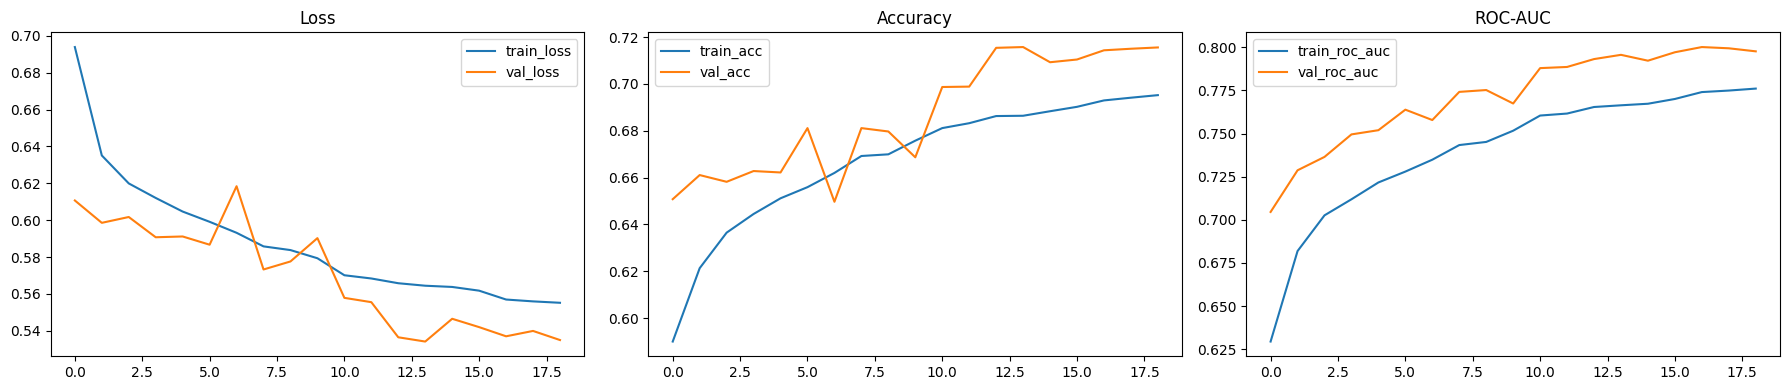

In [11]:
# Plot training curves
hist = history.history

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist.get("loss", []), label="train_loss")
axes[0].plot(hist.get("val_loss", []), label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist.get("accuracy", []), label="train_acc")
axes[1].plot(hist.get("val_accuracy", []), label="val_acc")
axes[1].set_title("Accuracy")
axes[1].legend()

axes[2].plot(hist.get("roc_auc", []), label="train_roc_auc")
axes[2].plot(hist.get("val_roc_auc", []), label="val_roc_auc")
axes[2].set_title("ROC-AUC")
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
# Evaluate on test set with comprehensive benchmark metrics

y_true = []
y_prob = []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0).flatten()
    y_prob.extend(probs.tolist())
    y_true.extend(y_batch.numpy().flatten().astype(int).tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    "roc_auc": roc_auc_score(y_true, y_prob),
    "pr_auc": average_precision_score(y_true, y_prob),
    "mcc": matthews_corrcoef(y_true, y_pred),
    "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    "sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "npv": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
    "fpr": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    "fnr": fn / (fn + tp) if (fn + tp) > 0 else 0.0,
}

print("=== Test Benchmark Metrics ===")
for k, v in metrics.items():
    print(f"{k:>18}: {v:.4f}")

print("\n=== Confusion Matrix ===")
print(np.array([[tn, fp], [fn, tp]]))

print("\n=== Classification Report ===")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

=== Test Benchmark Metrics ===
          accuracy: 0.7168
         precision: 0.6080
            recall: 0.8149
          f1_score: 0.6964
 balanced_accuracy: 0.7333
           roc_auc: 0.7978
            pr_auc: 0.6690
               mcc: 0.4580
       specificity: 0.6517
       sensitivity: 0.8149
               npv: 0.8415
               fpr: 0.3483
               fnr: 0.1851

=== Confusion Matrix ===
[[7072 3780]
 [1332 5864]]

=== Classification Report ===
              precision    recall  f1-score   support

        fake     0.8415    0.6517    0.7345     10852
        real     0.6080    0.8149    0.6964      7196

    accuracy                         0.7168     18048
   macro avg     0.7248    0.7333    0.7155     18048
weighted avg     0.7484    0.7168    0.7193     18048



In [13]:
# Optional: save trained model
SAVE_PATH = Path("deep_dense_cnn_ai_vs_real.keras")
model.save(SAVE_PATH)
print("Model saved to:", SAVE_PATH.resolve())

Model saved to: /kaggle/working/deep_dense_cnn_ai_vs_real.keras


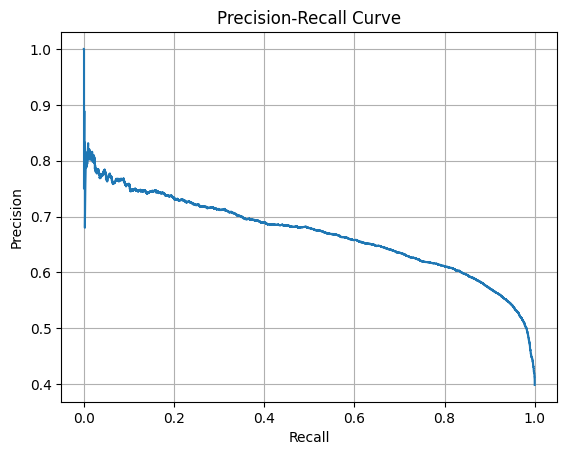

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

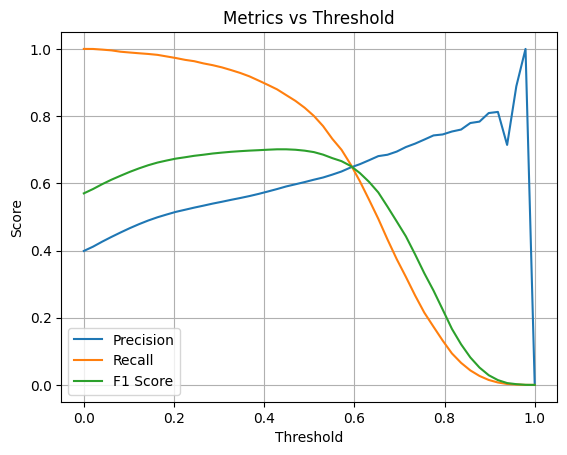

In [15]:
import numpy as np

thresholds = np.linspace(0.0, 1.0, 50)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    p = precision_score(y_true, y_pred_t, zero_division=0)
    r = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    
    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [16]:
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (F1): {best_threshold:.3f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall: {recalls[best_idx]:.4f}")
print(f"F1: {f1s[best_idx]:.4f}")

Best Threshold (F1): 0.429
Precision: 0.5830
Recall: 0.8797
F1: 0.7012


In [17]:
for t, p, r in zip(thresholds, precisions, recalls):
    if r >= 0.6:
        print(f"Threshold: {t:.3f}, Precision: {p:.4f}, Recall: {r:.4f}")
        break

Threshold: 0.000, Precision: 0.3987, Recall: 1.0000


In [18]:
t = best_threshold  # or any value
y_pred_t = (y_prob >= t).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

print(f"\nThreshold: {t:.3f}")
print(np.array([[tn, fp], [fn, tp]]))


Threshold: 0.429
[[6324 4528]
 [ 866 6330]]


Loaded inference model from: /kaggle/working/deep_dense_cnn_ai_vs_real.keras
Last Conv Layer used for Grad-CAM: conv2d_7


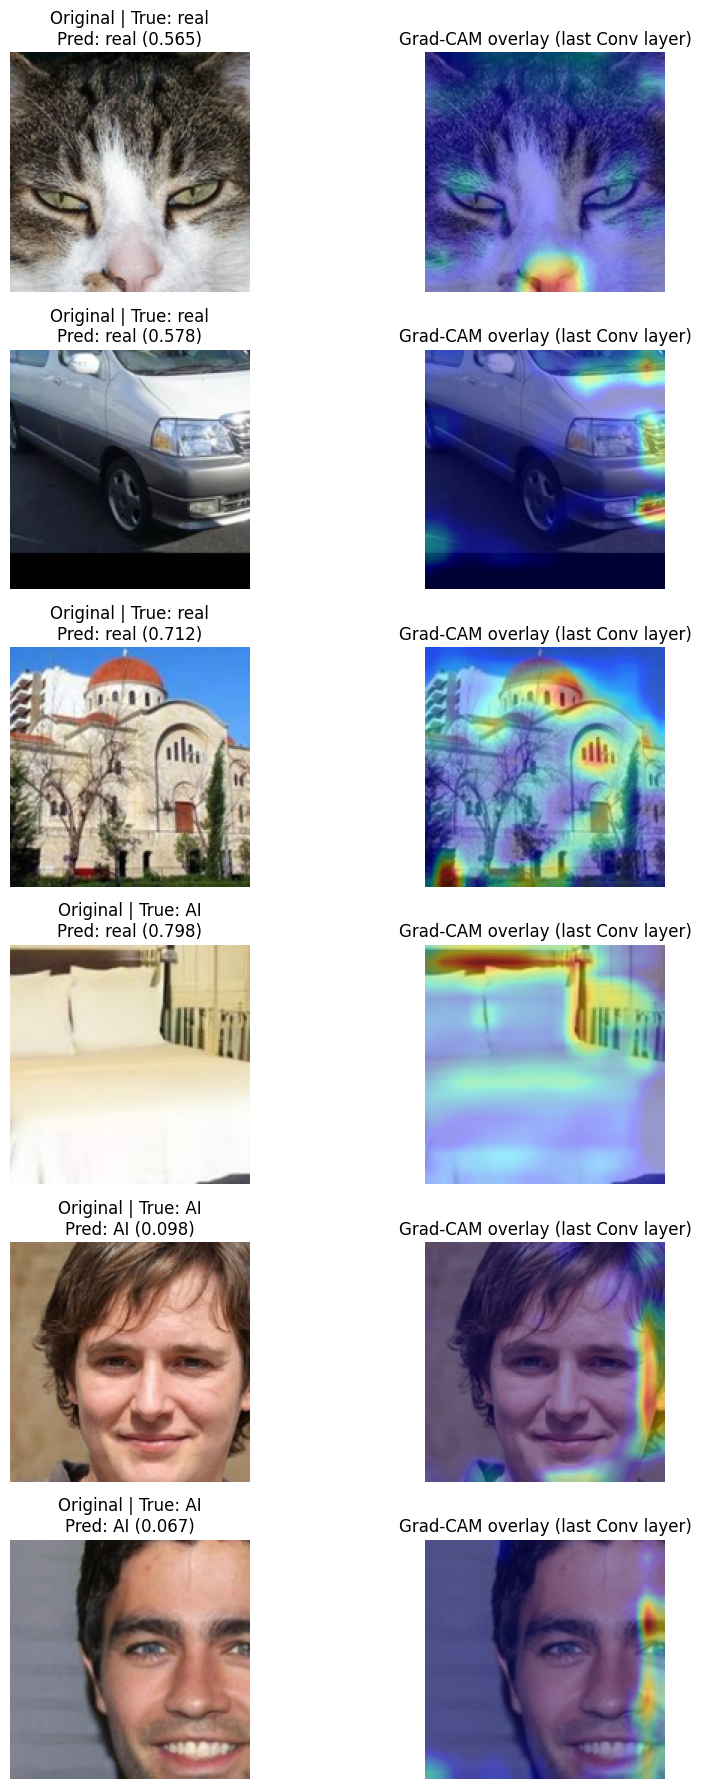

Conv layers used for per-layer Grad-CAM: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4', 'conv2d_5', 'conv2d_6', 'conv2d_7']


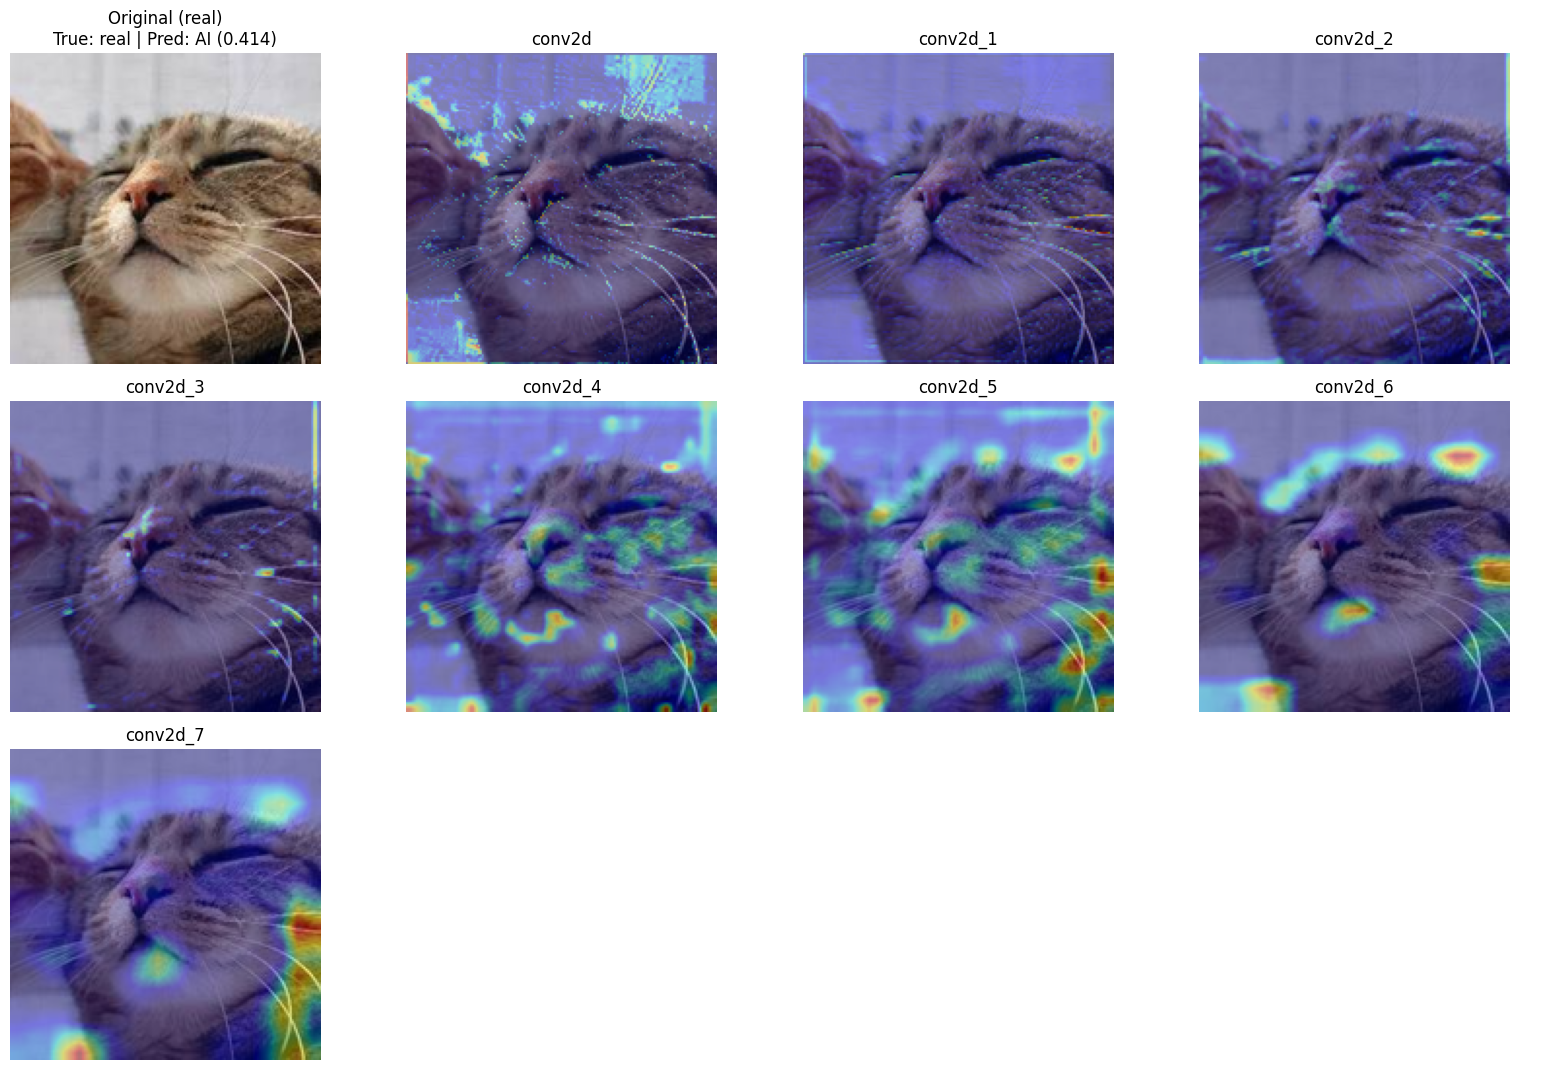

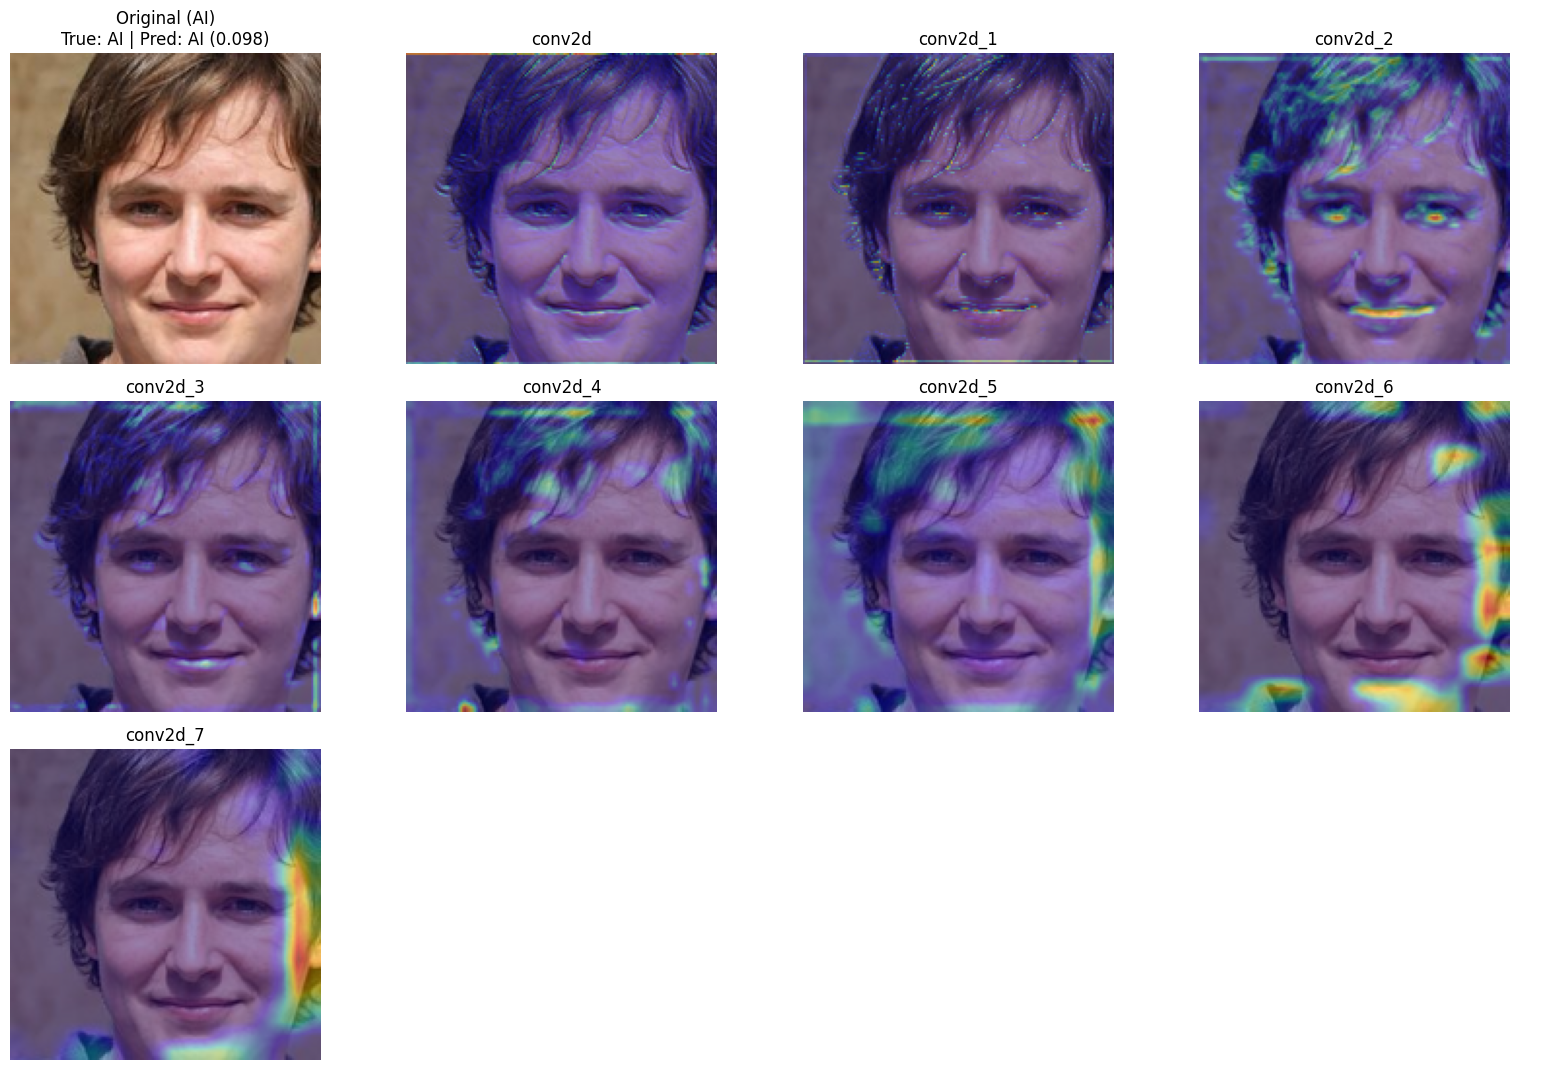

In [21]:
# Inference + Grad-CAM visualization using saved model/weights
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

LABEL_TO_NAME = {0: "AI", 1: "real"}


def build_deep_dense_cnn_for_inference(img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    """Rebuild the training architecture so weights can be loaded after a fresh kernel restart."""
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.12),
            tf.keras.layers.RandomZoom(0.15),
            tf.keras.layers.RandomContrast(0.15),
        ],
        name="augmentation",
    )

    inputs = tf.keras.Input(shape=(img_height, img_width, 3))
    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255.0)(x)

    x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model(inputs, outputs, name="deep_dense_cnn")


def load_inference_model():
    """Load full saved model when available, otherwise rebuild architecture and load weights."""
    candidate_paths = [
        Path("deep_dense_cnn_ai_vs_real.keras"),
        Path("deep_dense_cnn_ai_vs_real.weights.h5"),
    ]

    chosen = None
    for p in candidate_paths:
        if p.exists():
            chosen = p
            break

    if chosen is None:
        raise FileNotFoundError(
            "No saved model/weights found. Expected one of: "
            "deep_dense_cnn_ai_vs_real.keras or deep_dense_cnn_ai_vs_real.weights.h5"
        )

    if chosen.suffix == ".keras":
        loaded_model = tf.keras.models.load_model(chosen, compile=False)
    else:
        loaded_model = build_deep_dense_cnn_for_inference()
        loaded_model.load_weights(chosen)

    print(f"Loaded inference model from: {chosen.resolve()}")
    return loaded_model


def sample_images_by_label(hf_split, label_id, n_samples=3, seed=SEED):
    labels = np.asarray(hf_split["label"], dtype=np.int32)
    candidate_indices = np.where(labels == label_id)[0]
    if len(candidate_indices) == 0:
        raise ValueError(f"No samples found for label {label_id} ({LABEL_TO_NAME[label_id]}).")

    rng = np.random.default_rng(seed + label_id)
    n_pick = min(n_samples, len(candidate_indices))
    chosen_indices = rng.choice(candidate_indices, size=n_pick, replace=False)

    samples = []
    for idx in chosen_indices:
        pil_img = hf_split[int(idx)]["image"].convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
        img_uint8 = np.asarray(pil_img, dtype=np.uint8)
        img_float = img_uint8.astype(np.float32) / 255.0
        samples.append((img_float, label_id))

    return samples


def get_last_conv_layer_name(loaded_model):
    for layer in reversed(loaded_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model for Grad-CAM.")


def get_all_conv_layer_names(loaded_model):
    conv_layers = [layer.name for layer in loaded_model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    if not conv_layers:
        raise ValueError("No Conv2D layers found in model.")
    return conv_layers


def make_gradcam_heatmap(img_float, loaded_model, conv_layer_name):
    img_tensor = tf.convert_to_tensor(np.expand_dims((img_float * 255.0).astype(np.float32), axis=0))

    grad_model = tf.keras.models.Model(
        loaded_model.inputs,
        [loaded_model.get_layer(conv_layer_name).output, loaded_model.output],
    )

    with tf.GradientTape() as tape:
        model_inputs = [img_tensor] if isinstance(loaded_model.inputs, (list, tuple)) else img_tensor
        conv_outputs, predictions = grad_model(model_inputs, training=False)
        score = predictions[:, 0]

    grads = tape.gradient(score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + tf.keras.backend.epsilon())

    heatmap = heatmap.numpy()
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (IMG_HEIGHT, IMG_WIDTH)).numpy().squeeze()
    return np.clip(heatmap, 0.0, 1.0)


def overlay_heatmap(img_float, heatmap, alpha=0.40, cmap_name="jet"):
    cmap = plt.get_cmap(cmap_name)
    heatmap_rgb = cmap(heatmap)[..., :3]
    return np.clip((1.0 - alpha) * img_float + alpha * heatmap_rgb, 0.0, 1.0)


def show_samples_with_gradcam(loaded_model, hf_split, n_real=3, n_fake=3):
    real_samples = sample_images_by_label(hf_split, label_id=1, n_samples=n_real)
    fake_samples = sample_images_by_label(hf_split, label_id=0, n_samples=n_fake)
    all_samples = real_samples + fake_samples

    last_conv_name = get_last_conv_layer_name(loaded_model)
    print("Last Conv Layer used for Grad-CAM:", last_conv_name)

    fig, axes = plt.subplots(len(all_samples), 2, figsize=(10, 3 * len(all_samples)))
    if len(all_samples) == 1:
        axes = np.array([axes])

    for i, (img_float, true_label) in enumerate(all_samples):
        pred_input = np.expand_dims((img_float * 255.0).astype(np.float32), axis=0)
        pred_prob = float(loaded_model(pred_input, training=False).numpy()[0, 0])
        pred_label = int(pred_prob >= 0.5)

        heatmap = make_gradcam_heatmap(img_float, loaded_model, last_conv_name)
        overlay = overlay_heatmap(img_float, heatmap, alpha=0.40)

        axes[i, 0].imshow(img_float)
        axes[i, 0].set_title(
            f"Original | True: {LABEL_TO_NAME[true_label]}\n"
            f"Pred: {LABEL_TO_NAME[pred_label]} ({pred_prob:.3f})"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title("Grad-CAM overlay (last Conv layer)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


def show_all_conv_layers_for_one_real_one_ai(loaded_model, hf_split, seed=SEED):
    """Show per-conv-layer Grad-CAM overlays for exactly one real and one AI sample."""
    samples = [
        ("real", sample_images_by_label(hf_split, label_id=1, n_samples=1, seed=seed)[0]),
        ("AI", sample_images_by_label(hf_split, label_id=0, n_samples=1, seed=seed)[0]),
    ]

    conv_layers = get_all_conv_layer_names(loaded_model)
    print("Conv layers used for per-layer Grad-CAM:", conv_layers)

    for display_name, (img_float, true_label) in samples:
        pred_input = np.expand_dims((img_float * 255.0).astype(np.float32), axis=0)
        pred_prob = float(loaded_model(pred_input, training=False).numpy()[0, 0])
        pred_label = int(pred_prob >= 0.5)

        total_panels = 1 + len(conv_layers)
        cols = 4
        rows = int(np.ceil(total_panels / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
        axes = np.array(axes).reshape(-1)

        axes[0].imshow(img_float)
        axes[0].set_title(
            f"Original ({display_name})\n"
            f"True: {LABEL_TO_NAME[true_label]} | Pred: {LABEL_TO_NAME[pred_label]} ({pred_prob:.3f})"
        )
        axes[0].axis("off")

        for j, layer_name in enumerate(conv_layers, start=1):
            heatmap = make_gradcam_heatmap(img_float, loaded_model, layer_name)
            overlay = overlay_heatmap(img_float, heatmap, alpha=0.40)
            axes[j].imshow(overlay)
            axes[j].set_title(f"{layer_name}")
            axes[j].axis("off")

        for k in range(total_panels, len(axes)):
            axes[k].axis("off")

        plt.tight_layout()
        plt.show()


# Run inference demo.
inference_model = load_inference_model()

# 1) Existing view: 3 real + 3 AI with only last conv layer heatmap.
show_samples_with_gradcam(inference_model, test_raw, n_real=3, n_fake=3)

# 2) New view: all conv layers for exactly 1 real and 1 AI image.
show_all_conv_layers_for_one_real_one_ai(inference_model, test_raw, seed=SEED)